# Visualizaciones

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from IPython.display import display, clear_output

import numpy as np
import scipy

plt.style.use('seaborn-v0_8-darkgrid') 

%matplotlib inline

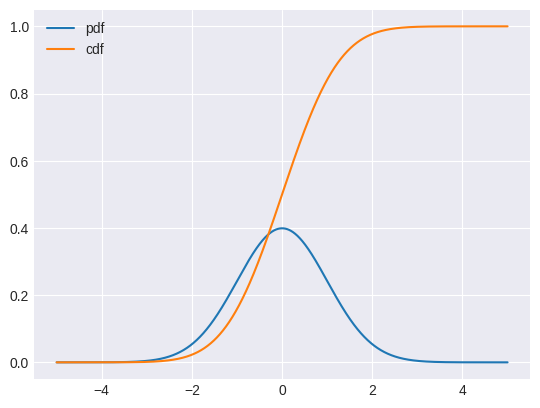

In [2]:
x = np.linspace(-5, 5, 5000)
mu = 0
sigma = 1

y_pdf = scipy.stats.norm.pdf(x, mu, sigma) # the normal pdf
y_cdf = scipy.stats.norm.cdf(x, mu, sigma) # the normal cdf

plt.plot(x, y_pdf, label='pdf')
plt.plot(x, y_cdf, label='cdf')
plt.legend();

In [11]:
# Function to draw the plot
def plot_normal(mean, std, interval1):
    x = np.linspace(-10, 10, 400)
    y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std)**2)

    with output:
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        plt.plot(x, y, color='steelblue')


        # Shade first interval
        mask1 = (x >= interval1[0]) & (x <= interval1[1])
        plt.fill_between(x[mask1], y[mask1], color='orange', alpha=0.5, label='Interval 1')

        
        plt.title(f'Normal Distribution (mean={mean:.2f}, std={std:.2f})')
        plt.xlabel('x')
        plt.ylabel('Density')
        plt.grid(True)
        plt.show()

# Sliders
mean_slider = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description='Mean')
std_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Std Dev')

interval1_slider = widgets.FloatRangeSlider(value=[-1.0, 1.0], min=-10, max=10, step=0.1, description='Interval 1')

# Output widget for the plot
output = widgets.Output()

def update_plot(change=None):
    plot_normal(mean_slider.value, std_slider.value, interval1_slider.value)

# Observe slider changes and update plot
mean_slider.observe(update_plot, names='value')
std_slider.observe(update_plot, names='value')
interval1_slider.observe(update_plot, names='value')

# Initial plot
plot_normal(mean_slider.value, std_slider.value, interval1_slider.value)

# Display everything
display(widgets.VBox([mean_slider, std_slider, interval1_slider, output]))

In [23]:
output = widgets.Output()

# Updated plot function
def plot_normal(mean, std, interval1):
    x = np.linspace(-10, 10, 400)
    y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std)**2)

    with output:
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        plt.plot(x, y, color='steelblue', label='Normal Distribution')

        # Shade interval1 (q1 to q2)
        mask1 = (x >= interval1[0]) & (x <= interval1[1])
        plt.fill_between(x[mask1], y[mask1], color='orange', alpha=0.5, label='Interval 1')


        plt.title(f'Normal Distribution (mean={mean:.2f}, std={std:.2f})')
        plt.xlabel('x')
        plt.ylabel('Density')

        plt.xticks([])  # Hide x-axis ticks

        # Add q1 and q2 under interval1
        plt.text(interval1[0], -0.01, '$q_1$', ha='center', va='top', fontsize=12)
        plt.text(interval1[1], -0.01, '$q_2$', ha='center', va='top', fontsize=12)

        plt.ylim(bottom=-0.02)  # Space for q-labels
        plt.legend()
        plt.grid(True)
        plt.show()

# Sliders
mean_slider = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description='Mean')
std_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Std Dev')

interval1_slider = widgets.FloatRangeSlider(value=[-1.0, 1.0], min=-10, max=10, step=0.1, description='Interval 1')

# Update function
def update_plot(change=None):
    plot_normal(mean_slider.value, std_slider.value,
                interval1_slider.value)

# Observers
mean_slider.observe(update_plot, names='value')
std_slider.observe(update_plot, names='value')
interval1_slider.observe(update_plot, names='value')

# Initial plot
plot_normal(mean_slider.value, std_slider.value, interval1_slider.value)

# Display
display(widgets.VBox([mean_slider, std_slider, interval1_slider, output]))